In [10]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from scipy.special import softmax
import seaborn as sns
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr
import ipyvolume as ipv
import os
from pyreadr import read_r

from terminal_pareto import ParetoFront
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



t_threshold = 255
ts_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

t_threshold_2 = 247
ts_df_2 = pd.read_csv("./data/embryo2/tracks.txt", sep="\t")
ts_df_2 = ts_df_2.loc[ts_df_2["t"] <= t_threshold_2]
all_xyz_map_2 = {}
cell_names_2 = ts_df_2["name"].unique()
valid_cell_names_2 = []
for name in cell_names_2:
    time_points = ts_df_2.loc[ts_df_2['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold_2:
        continue
    all_xyz_map_2[name] = ts_df_2.loc[ts_df_2['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names_2.append(name)
valid_cell_names = set(valid_cell_names).intersection(set(valid_cell_names_2))

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [12]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
internal_node_dict = {}
terminal_name_to_idx = {}
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0:
        p_lookup_name = map_names(parent['did'])
        
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_ancestry[len(terminal_nodes)-1] = ancestors
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
    else:
        internal_node_dict[lookup_name] = {
            "node": node,
            "num_descendants": 0
        }
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [13]:
len(terminal_nodes)

286

In [14]:
alt_tracking = pd.read_csv("data/c_briggsae/nadin/output_2.csv", index_col=0)
alt_tracking

,last_time,x,y,z
cell,,,,
AB,23,287,303,11
ABa,45,219,317,12
ABal,68,182,247,12
ABala,93,165,271,10
ABalaa,142,139,292,11
...,...,...,...,...
Dpppa,398,378,383,11
Dpppp,394,416,374,8
P4,243,476,246,4


In [15]:
common_cells = set()
for cell in terminal_nodes:
    if cell in alt_tracking.index:
        common_cells.add(cell)
print(f"Number of common cells between lineage and tracking data: {len(common_cells)}")

Number of common cells between lineage and tracking data: 129


In [16]:
pair_wise_distances = []
pair_wise_distances_2 = []
alt_pair_wise_distances = []
for i, cell1 in tqdm(enumerate(common_cells)):
    for j, cell2 in enumerate(common_cells):
        if j <= i: continue
        xyz1 = all_xyz_map[cell1]
        xyz2 = all_xyz_map[cell2]
        dist = np.linalg.norm(xyz1 - xyz2)
        pair_wise_distances.append(dist)
        xyz1_2 = all_xyz_map_2[cell1]
        xyz2_2 = all_xyz_map_2[cell2]
        dist_2 = np.linalg.norm(xyz1_2 - xyz2_2)
        pair_wise_distances_2.append(dist_2)
        alt_xyz1 = alt_tracking.loc[cell1][["x", "y", "z"]].values
        alt_xyz2 = alt_tracking.loc[cell2][["x", "y", "z"]].values
        alt_dist = np.linalg.norm(alt_xyz1 - alt_xyz2)
        alt_pair_wise_distances.append(alt_dist)

0it [00:00, ?it/s]

129it [00:03, 32.85it/s]


In [17]:
# normalize distances to [0, 1]
pair_wise_distances = np.array(pair_wise_distances)
pair_wise_distances_2 = np.array(pair_wise_distances_2)
alt_pair_wise_distances = np.array(alt_pair_wise_distances)
pair_wise_distances = pair_wise_distances / np.max(pair_wise_distances)
pair_wise_distances_2 = pair_wise_distances_2 / np.max(pair_wise_distances_2)
alt_pair_wise_distances = alt_pair_wise_distances / np.max(alt_pair_wise_distances)
distances_diff = np.abs(pair_wise_distances - alt_pair_wise_distances)
print(f"Average pairwise distance difference: {np.mean(distances_diff)}")

Average pairwise distance difference: 0.07657701102903923


In [19]:
correlation, p_value = pearsonr(pair_wise_distances, alt_pair_wise_distances)
print(f"Pearson correlation squared: {correlation**2}, p-value: {p_value}")

spearman_correlation, spearman_p_value = spearmanr(pair_wise_distances, alt_pair_wise_distances)
print(f"Spearman correlation squared: {spearman_correlation**2}, p-value: {spearman_p_value}")

Pearson correlation squared: 0.7269697184943422, p-value: 0.0
Spearman correlation squared: 0.6550235273792482, p-value: 0.0


In [20]:
correlation, p_value = pearsonr(pair_wise_distances, pair_wise_distances_2)
print(f"Pearson correlation squared: {correlation**2}, p-value: {p_value}")

spearman_correlation, spearman_p_value = spearmanr(pair_wise_distances, pair_wise_distances_2)
print(f"Spearman correlation squared: {spearman_correlation**2}, p-value: {spearman_p_value}")

Pearson correlation squared: 0.9638636177970498, p-value: 0.0
Spearman correlation squared: 0.9582146577145393, p-value: 0.0


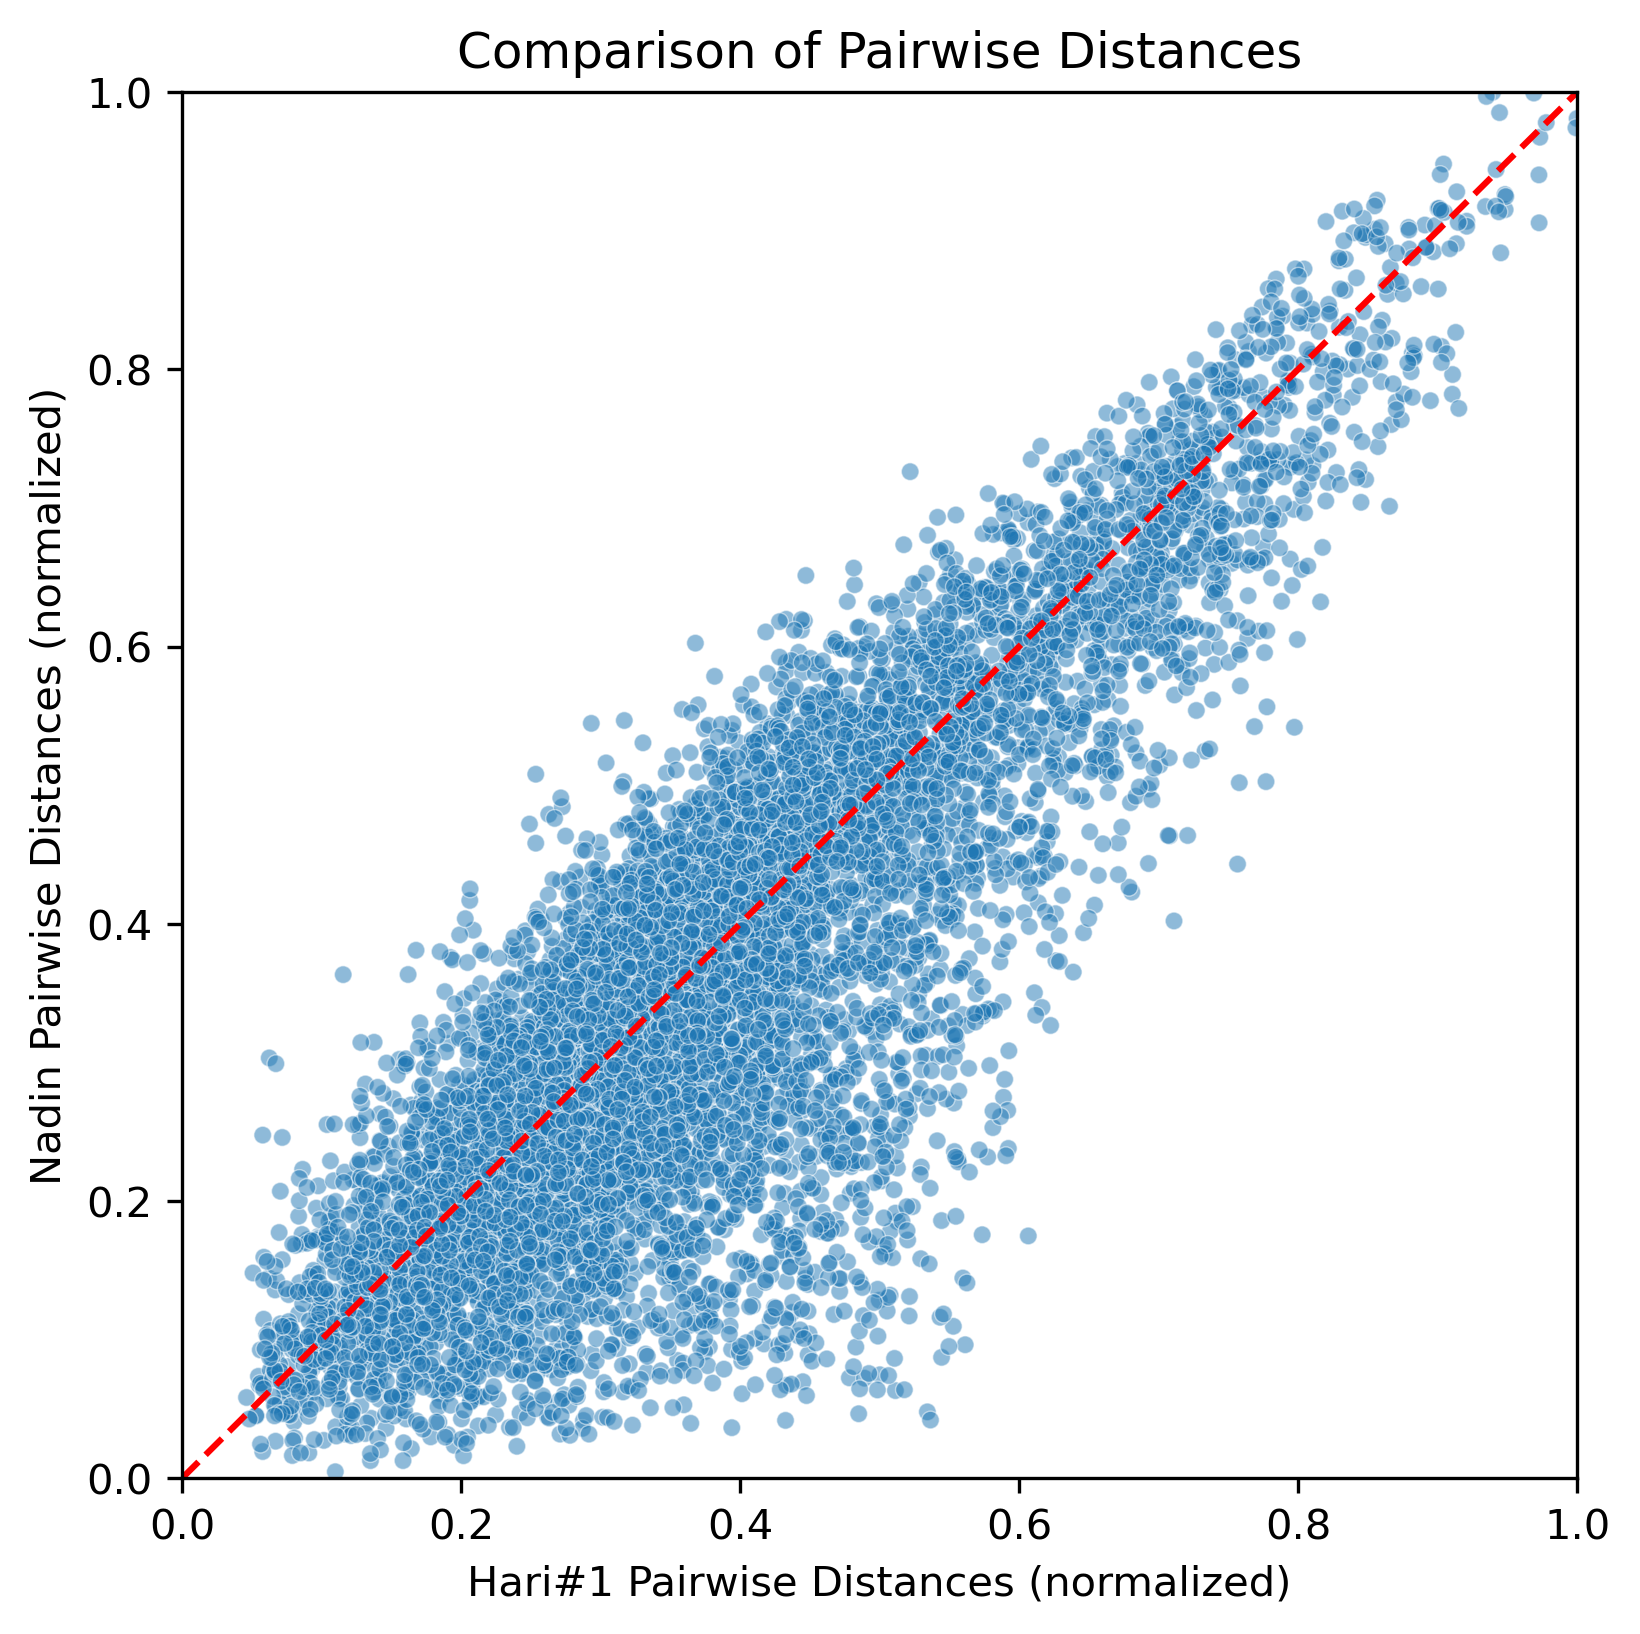

In [21]:
# plot the pairwise distances
plt.figure(figsize=(6, 6))
sns.scatterplot(x=pair_wise_distances, y=alt_pair_wise_distances, alpha=0.5, size=5)
plt.xlabel("Hari#1 Pairwise Distances (normalized)")
plt.ylabel("Nadin Pairwise Distances (normalized)")
plt.title("Comparison of Pairwise Distances")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim(0, 1)
plt.ylim(0, 1)
# hide legend
plt.legend().set_visible(False)
plt.show()

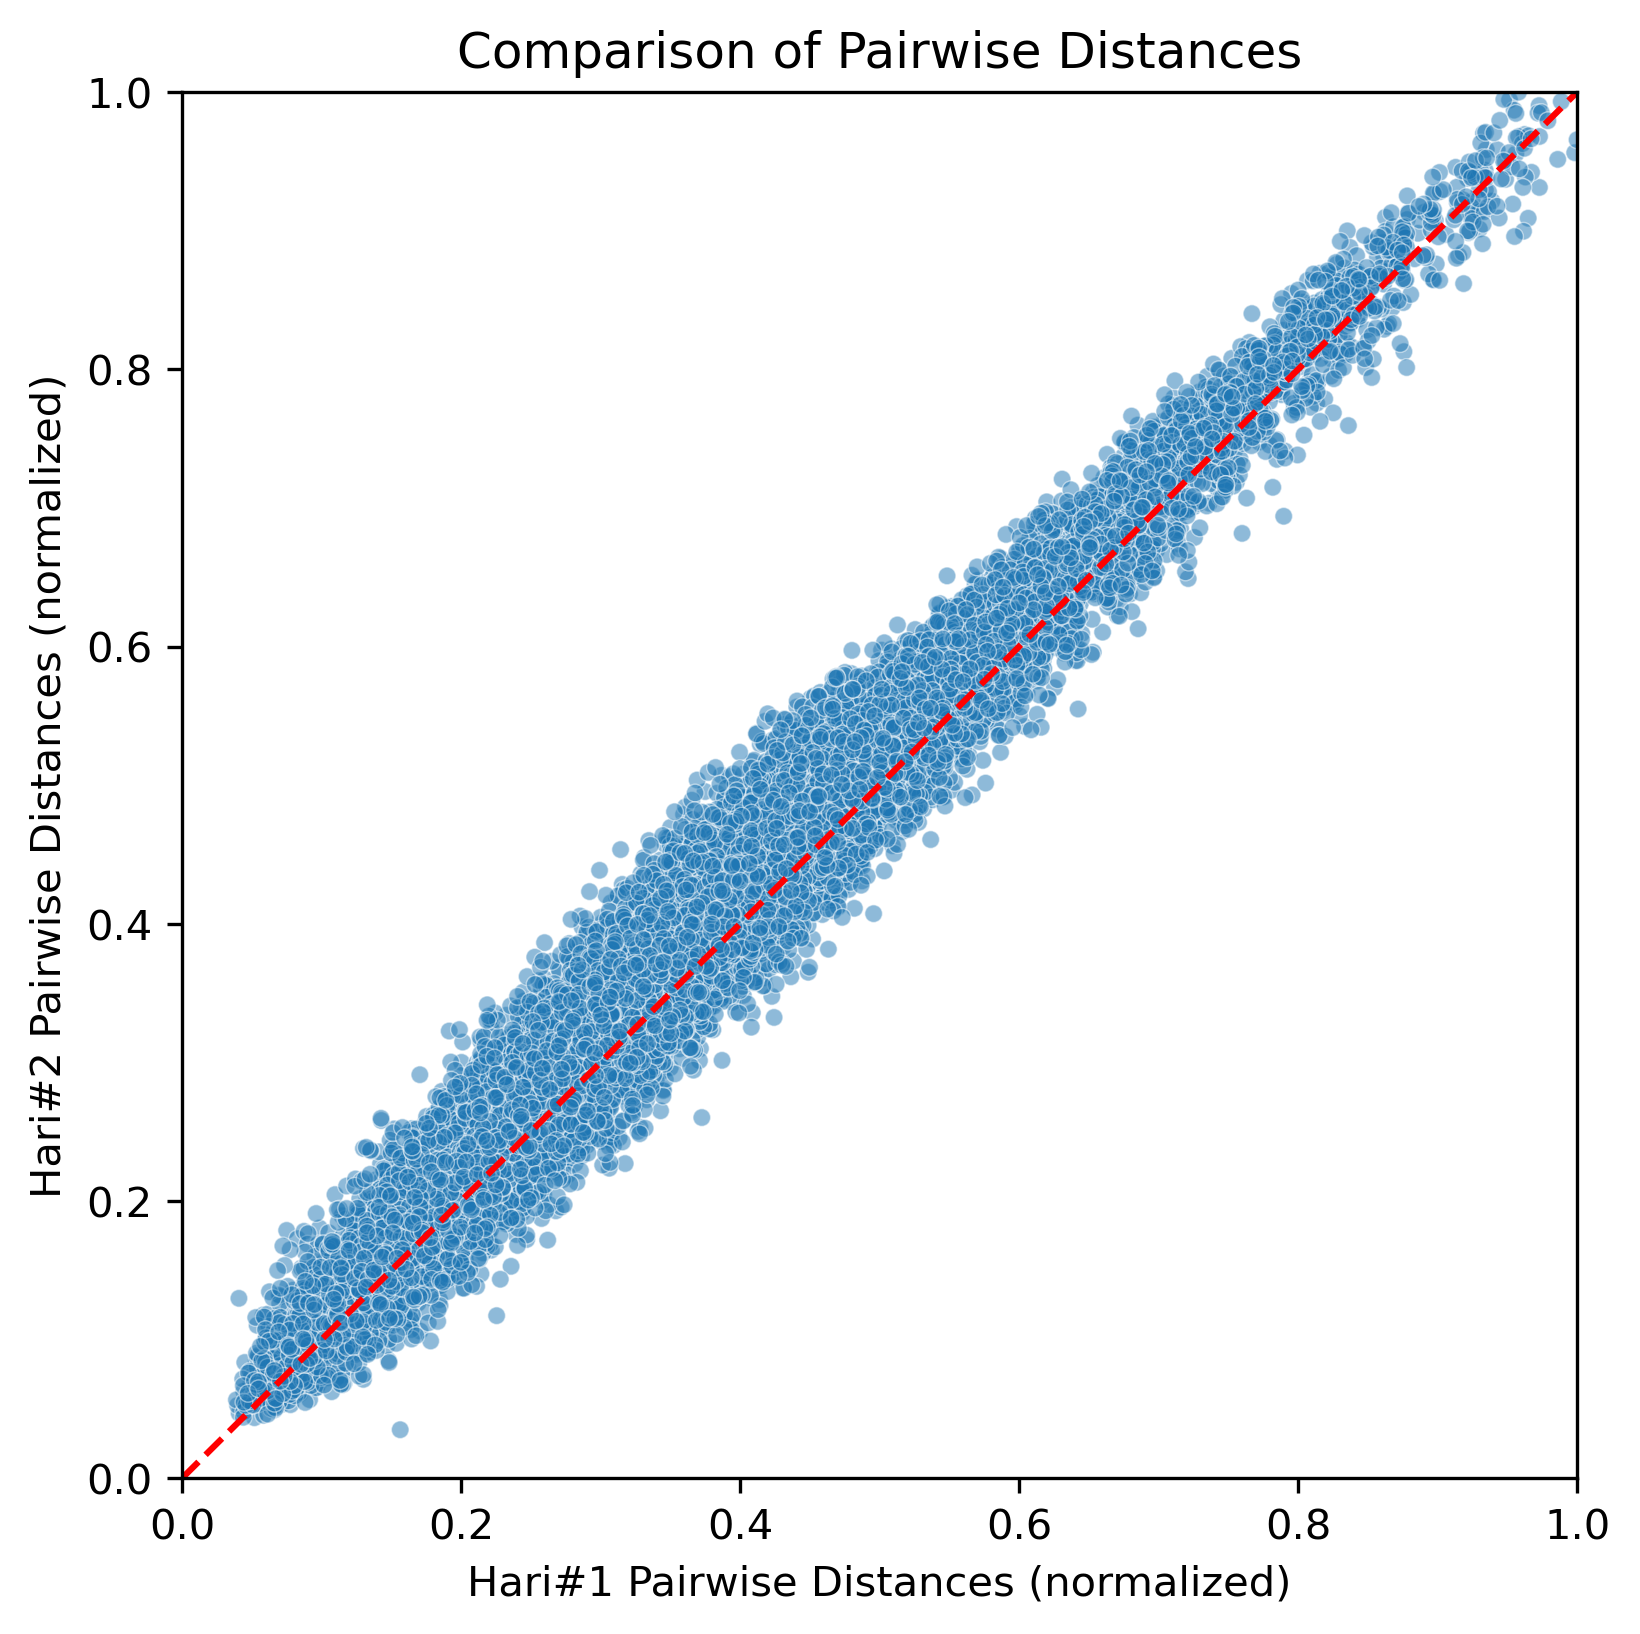

In [49]:
# plot the pairwise distances
plt.figure(figsize=(6, 6))
sns.scatterplot(x=pair_wise_distances, y=pair_wise_distances_2, alpha=0.5, size=5)
plt.xlabel("Hari#1 Pairwise Distances (normalized)")
plt.ylabel("Hari#2 Pairwise Distances (normalized)")
plt.title("Comparison of Pairwise Distances")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim(0, 1)
plt.ylim(0, 1)
# hide legend
plt.legend().set_visible(False)
plt.show()

In [22]:
yiming_tracking = pd.read_csv('data/c_briggsae/CD210519ZZY0874p1.csv')
yiming_tracking.head()

,cellTime,cell,time,none,global,local,blot,cross,z,x,y,size,gweight
0,ABa:1,ABa,1,0,0,0,0,0,23.7,520,278,74,3170497
1,ABa:2,ABa,2,0,0,0,0,0,17.0,532,294,74,4948622
2,ABa:3,ABa,3,0,0,0,0,0,14.8,554,300,78,7297108
3,ABa:4,ABa,4,0,0,0,0,0,20.3,550,284,82,9665030
4,ABa:5,ABa,5,0,0,0,0,0,19.9,555,267,86,6504621


In [23]:
max_overlap_time = 0
max_overlap_cells = 0
for t in yiming_tracking['time'].unique():
    yiming_cells = set(yiming_tracking[yiming_tracking['time'] == t]['cell'].values)
    overlap_cells = valid_cell_names.intersection(yiming_cells)
    if len(overlap_cells) > max_overlap_cells:
        max_overlap_cells = len(overlap_cells)
        max_overlap_time = t

In [24]:
yiming_last_track = yiming_tracking[yiming_tracking['time'] == max_overlap_time]

In [25]:
common_cells_with_yiming = common_cells.intersection(set(yiming_last_track['cell'].values))

In [26]:
pair_wise_distances = []
pair_wise_distances_nadin = []
pair_wise_distances_yiming = []
for i, cell1 in tqdm(enumerate(common_cells_with_yiming)):
    for j, cell2 in enumerate(common_cells_with_yiming):
        if j <= i: continue
        yiming_xyz1 = yiming_last_track[yiming_last_track['cell'] == cell1][['x', 'y', 'z']].values[0]
        yiming_xyz2 = yiming_last_track[yiming_last_track['cell'] == cell2][['x', 'y', 'z']].values[0]
        yiming_dist = np.linalg.norm(yiming_xyz1 - yiming_xyz2)
        nadin_xyz1 = alt_tracking.loc[cell1][["x", "y", "z"]].values
        nadin_xyz2 = alt_tracking.loc[cell2][["x", "y", "z"]].values
        nadin_dist = np.linalg.norm(nadin_xyz1 - nadin_xyz2)
        xyz1 = all_xyz_map[cell1]
        xyz2 = all_xyz_map[cell2]
        dist = np.linalg.norm(xyz1 - xyz2)
        pair_wise_distances.append(dist)
        pair_wise_distances_yiming.append(yiming_dist)
        pair_wise_distances_nadin.append(nadin_dist)


125it [00:10, 11.87it/s]


In [27]:
# normalize distances to [0, 1]
pair_wise_distances = np.array(pair_wise_distances)
pair_wise_distances_yiming = np.array(pair_wise_distances_yiming)
pair_wise_distances_nadin = np.array(pair_wise_distances_nadin)
pair_wise_distances = pair_wise_distances / np.max(pair_wise_distances)
pair_wise_distances_yiming = pair_wise_distances_yiming / np.max(pair_wise_distances_yiming)
pair_wise_distances_nadin = pair_wise_distances_nadin / np.max(pair_wise_distances_nadin)

In [28]:
correlation, p_value = pearsonr(pair_wise_distances_yiming, pair_wise_distances_nadin)
print(f"Pearson correlation squared: {correlation**2}, p-value: {p_value}")

spearman_correlation, spearman_p_value = spearmanr(pair_wise_distances_yiming, pair_wise_distances_nadin)
print(f"Spearman correlation squared: {spearman_correlation**2}, p-value: {spearman_p_value}")

Pearson correlation squared: 0.8928243118541341, p-value: 0.0
Spearman correlation squared: 0.8704023116404886, p-value: 0.0


In [29]:
correlation, p_value = pearsonr(pair_wise_distances, pair_wise_distances_nadin)
print(f"Pearson correlation squared: {correlation**2}, p-value: {p_value}")

spearman_correlation, spearman_p_value = spearmanr(pair_wise_distances, pair_wise_distances_nadin)
print(f"Spearman correlation squared: {spearman_correlation**2}, p-value: {spearman_p_value}")

Pearson correlation squared: 0.7208666987518396, p-value: 0.0
Spearman correlation squared: 0.6513422374237392, p-value: 0.0


In [30]:
correlation, p_value = pearsonr(pair_wise_distances_yiming, pair_wise_distances)
print(f"Pearson correlation squared: {correlation**2}, p-value: {p_value}")

spearman_correlation, spearman_p_value = spearmanr(pair_wise_distances_yiming, pair_wise_distances)
print(f"Spearman correlation squared: {spearman_correlation**2}, p-value: {spearman_p_value}")

Pearson correlation squared: 0.7007756790127317, p-value: 0.0
Spearman correlation squared: 0.6312081230528425, p-value: 0.0


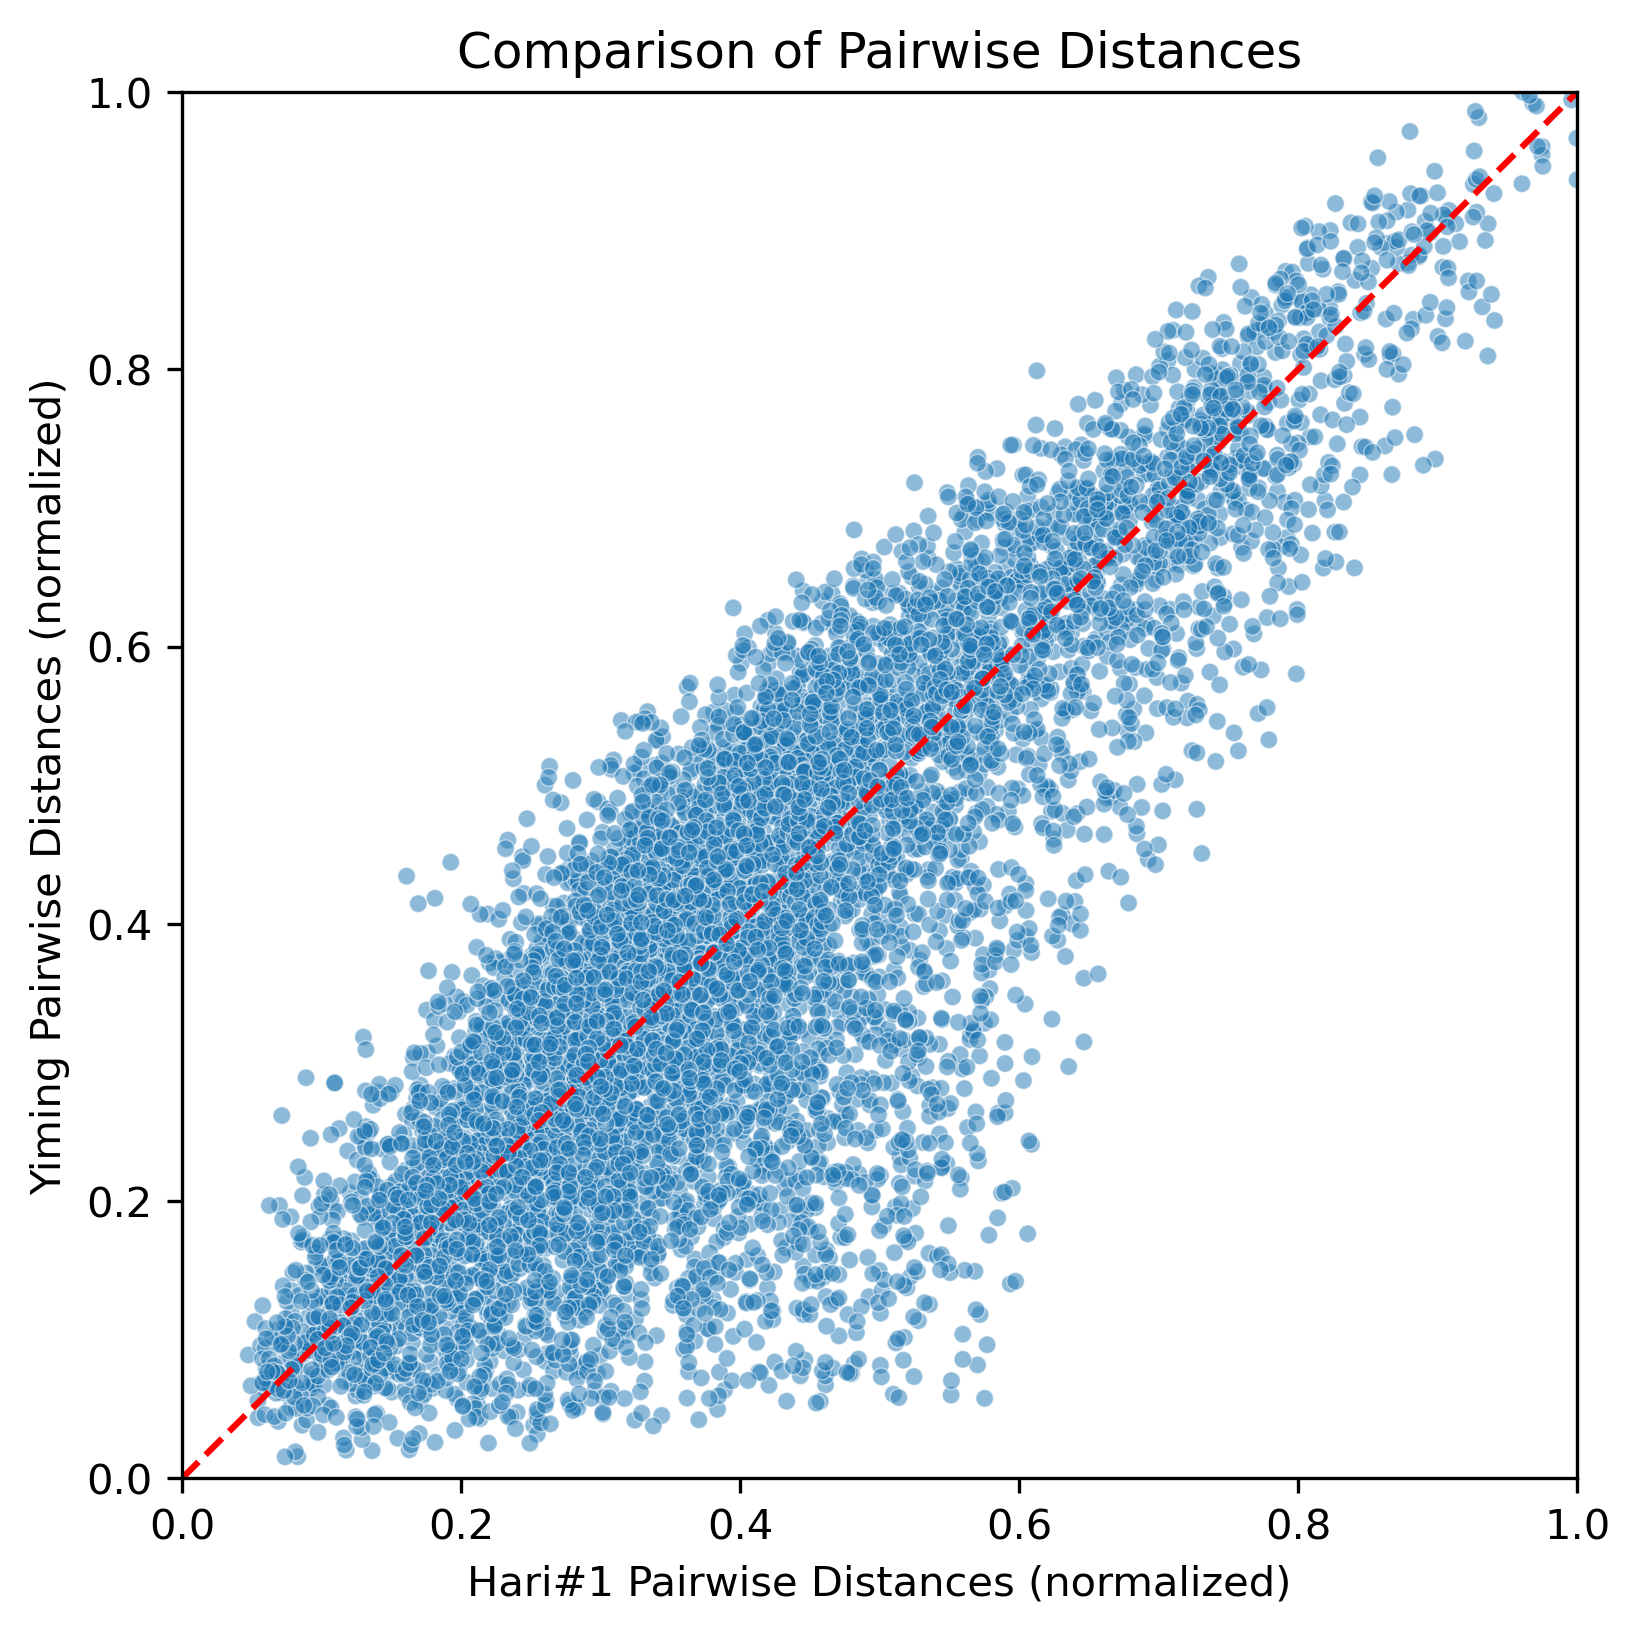

In [31]:
# plot the pairwise distances
plt.figure(figsize=(6, 6))
sns.scatterplot(x=pair_wise_distances, y=pair_wise_distances_yiming, alpha=0.5, size=5)
plt.xlabel("Hari#1 Pairwise Distances (normalized)")
plt.ylabel("Yiming Pairwise Distances (normalized)")
plt.title("Comparison of Pairwise Distances")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim(0, 1)
plt.ylim(0, 1)
# hide legend
plt.legend().set_visible(False)
plt.show()

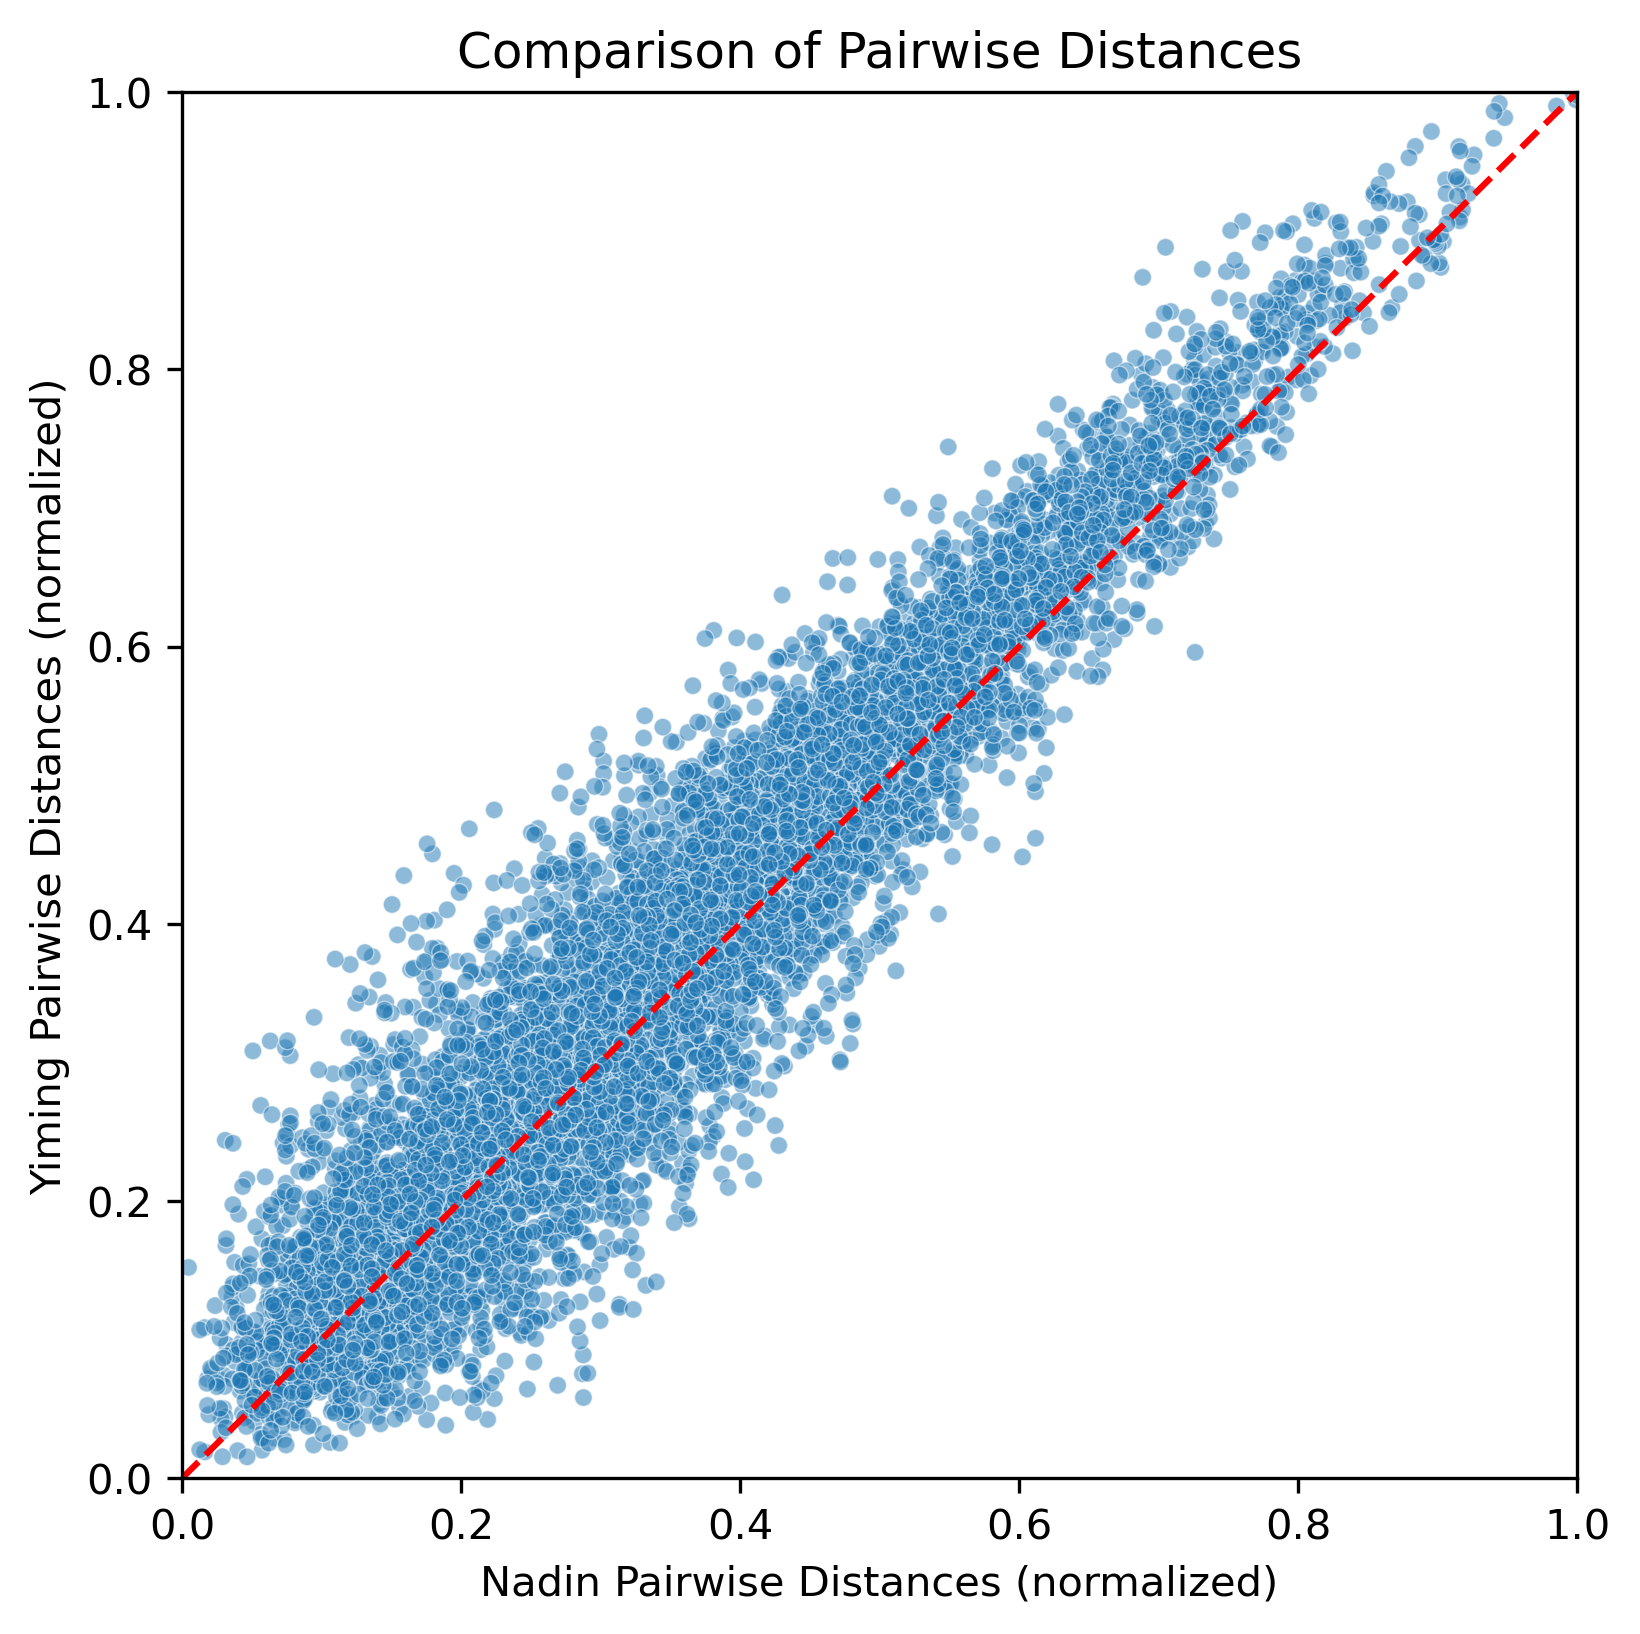

In [33]:
# plot the pairwise distances
plt.figure(figsize=(6, 6))
sns.scatterplot(x=pair_wise_distances_nadin, y=pair_wise_distances_yiming, alpha=0.5, size=5)
plt.xlabel("Nadin Pairwise Distances (normalized)")
plt.ylabel("Yiming Pairwise Distances (normalized)")
plt.title("Comparison of Pairwise Distances")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim(0, 1)
plt.ylim(0, 1)
# hide legend
plt.legend().set_visible(False)
plt.show()